In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [11]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\aatik\Downloads\60-days-data-science-main\60-days-data-science-main
['classification_foundations.ipynb', 'cleaned_statsfinal.csv', 'dataset_analysis.ipynb', 'data_cleaning.ipynb', 'day1.py', 'day14_performance_comparison.csv', 'day2.py', 'day3.py', 'eda_analysis.ipynb', 'feature_engineered_statsfinal.csv', 'feature_engineered_statsfinal.zip', 'feature_engineering.ipynb', 'grade_summary.txt', 'ml_foundations.ipynb', 'model_comparison.csv', 'model_optimization.ipynb', 'prediction_outputs.csv', 'README.md', 'regression_coefficients.csv', 'regression_modeling.ipynb', 'regression_predictions.csv', 'sales_analysis.py', 'sprint2_review.ipynb', 'statsfinal.csv', 'students.csv', 'WA_FnUseC_TelcoCustomerChurn.csv']


In [12]:
import os

csv_files = [file for file in os.listdir() if file.endswith(".csv")]

print("CSV files found:")
print(csv_files)

CSV files found:
['cleaned_statsfinal.csv', 'day14_performance_comparison.csv', 'feature_engineered_statsfinal.csv', 'model_comparison.csv', 'prediction_outputs.csv', 'regression_coefficients.csv', 'regression_predictions.csv', 'statsfinal.csv', 'students.csv', 'WA_FnUseC_TelcoCustomerChurn.csv']


In [13]:
df = pd.read_csv("cleaned_statsfinal.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset loaded successfully!
Shape: (4600, 12)

Columns:
['Unnamed: 0', 'Date', 'Q-P1', 'Q-P2', 'Q-P3', 'Q-P4', 'S-P1', 'S-P2', 'S-P3', 'S-P4', 'Total_Sales', 'Total_Quantity']


In [14]:
print(df.head())
print("\nData types:")
print(df.dtypes)

   Unnamed: 0        Date  Q-P1  Q-P2  Q-P3  Q-P4      S-P1      S-P2  \
0           0  2010-06-13  5422  3725   576   907  17187.74  23616.50   
1           1  2010-06-14  7047   779  3578  1574  22338.99   4938.86   
2           2  2010-06-15  1572  2082   595  1145   4983.24  13199.88   
3           3  2010-06-16  5657  2399  3140  1672  17932.69  15209.66   
4           4  2010-06-17  3668  3207  2184   708  11627.56  20332.38   

       S-P3      S-P4  Total_Sales  Total_Quantity  
0   3121.92   6466.91     50393.07           10630  
1  19392.76  11222.62     57893.23           12978  
2   3224.90   8163.85     29571.87            5394  
3  17018.80  11921.36     62082.51           12868  
4  11837.28   5048.04     48845.26            9767  

Data types:
Unnamed: 0          int64
Date                  str
Q-P1                int64
Q-P2                int64
Q-P3                int64
Q-P4                int64
S-P1              float64
S-P2              float64
S-P3              floa

In [15]:
print("\nUnique values in each column:")
for column in df.columns:
    print(column, ":", df[column].nunique())


Unique values in each column:
Unnamed: 0 : 4600
Date : 4574
Q-P1 : 3488
Q-P2 : 2667
Q-P3 : 3166
Q-P4 : 1631
S-P1 : 3488
S-P2 : 2667
S-P3 : 3166
S-P4 : 1631
Total_Sales : 4599
Total_Quantity : 3751


In [16]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if "churn" in file.lower() and file.endswith(".csv"):
            print(os.path.join(root, file))

.\WA_FnUseC_TelcoCustomerChurn.csv


In [17]:
df = pd.read_csv("WA_FnUseC_TelcoCustomerChurn.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())

Dataset loaded successfully!
Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport S

In [18]:
print("Columns:")
print(df.columns.tolist())

print("\nChurn values:")
print(df["Churn"].value_counts())

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Churn values:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [19]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [20]:
target = "Churn"

X = df.drop(columns=[target])
y = df[target].map({"Yes": 1, "No": 0})

print("Target:", target)
print("Features:", X.columns.tolist())
print("\nTarget values:")
print(y.value_counts())

Target: Churn
Features: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

Target values:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [21]:
X = pd.get_dummies(X, drop_first=True)

print("Features after encoding:", X.shape)
print(X.head())

Features after encoding: (7043, 13601)
   SeniorCitizen  tenure  MonthlyCharges  customerID_0003-MKNFE  \
0              0       1           29.85                  False   
1              0      34           56.95                  False   
2              0       2           53.85                  False   
3              0      45           42.30                  False   
4              0       2           70.70                  False   

   customerID_0004-TLHLJ  customerID_0011-IGKFF  customerID_0013-EXCHZ  \
0                  False                  False                  False   
1                  False                  False                  False   
2                  False                  False                  False   
3                  False                  False                  False   
4                  False                  False                  False   

   customerID_0013-MHZWF  customerID_0013-SMEOE  customerID_0014-BMAQU  ...  \
0                  False          

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 13601)
Testing data: (1409, 13601)


In [23]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [24]:
y_pred = logistic_model.predict(X_test)

print("Predictions generated successfully!")
print(y_pred[:20])

Predictions generated successfully!
[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [25]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7955997161107168

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



Confusion Matrix:
[[918 117]
 [171 203]]


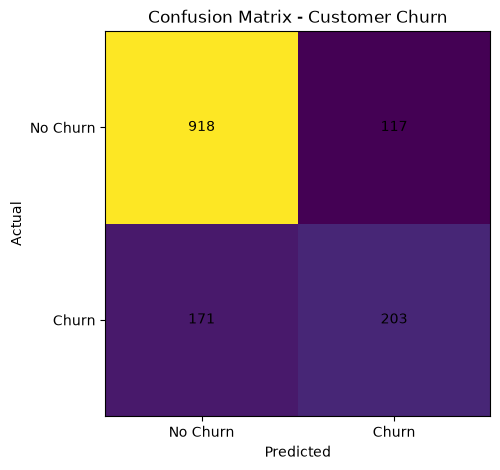

In [26]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix - Customer Churn")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [27]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 918
False Positives: 117
False Negatives: 171
True Positives: 203


In [28]:
prediction_results = pd.DataFrame({
    "Actual_Churn": y_test.values,
    "Predicted_Churn": y_pred
})

prediction_results["Actual_Churn"] = prediction_results["Actual_Churn"].map({
    0: "No",
    1: "Yes"
})

prediction_results["Predicted_Churn"] = prediction_results["Predicted_Churn"].map({
    0: "No",
    1: "Yes"
})

prediction_results.to_csv(
    "churn_predictions.csv",
    index=False
)

print("Prediction results saved successfully!")

Prediction results saved successfully!


# Day 15 — Classification Foundations

## Business Implications of Prediction Errors

### False Positive

A false positive occurs when the model predicts that a customer will churn, but the customer actually stays.

**Business impact:**
- The company may spend retention resources unnecessarily.
- Discounts or special offers may be given to customers who did not need them.
- However, the cost may be acceptable if retention campaigns are relatively inexpensive.

### False Negative

A false negative occurs when the model predicts that a customer will stay, but the customer actually churns.

**Business impact:**
- A potentially valuable customer may be missed by the retention team.
- The company may lose revenue because no preventive action was taken.
- False negatives can therefore be particularly important in a churn-prediction system.

### Key Learning

Classification models should not be evaluated only using accuracy. False positives and false negatives can have different business costs, so precision and recall are also important.# Day 15 — Classification Foundations

## Business Implications of Prediction Errors

### False Positive

A false positive occurs when the model predicts that a customer will churn, but the customer actually stays.

**Business impact:**
- The company may spend retention resources unnecessarily.
- Discounts or special offers may be given to customers who did not need them.
- However, the cost may be acceptable if retention campaigns are relatively inexpensive.

### False Negative

A false negative occurs when the model predicts that a customer will stay, but the customer actually churns.

**Business impact:**
- A potentially valuable customer may be missed by the retention team.
- The company may lose revenue because no preventive action was taken.
- False negatives can therefore be particularly important in a churn-prediction system.

### Key Learning

Classification models should not be evaluated only using accuracy. False positives and false negatives can have different business costs, so precision and recall are also important.

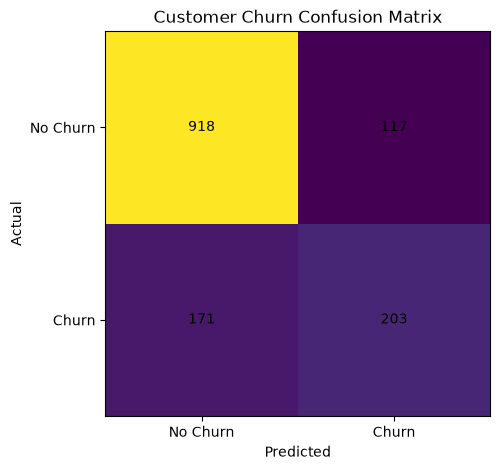

Confusion matrix saved successfully!


In [29]:
plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Customer Churn Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.savefig("confusion_matrix.png", bbox_inches="tight")
plt.show()

print("Confusion matrix saved successfully!")